<a href="https://colab.research.google.com/github/saivigneshmuthyam1/Celebal-Excellence-Internship/blob/main/week2_Sai_Vignesh_Muthyam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tesla EV Deliveries & Production — End to End Enterprise ML Pipeline
Designed and implemented an end-to-end Machine Learning pipeline on real-world multi-year vehicle data covering Preprocessing, Component Decomposition, Window Feature Engineering, Scaled Preprocessing, Cross-Validated Grid Searches, and Deep Multi-Metric Forecast Backtesting.


In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

## Automated Dataset Retrieval (via Kagglehub Cache)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tesla-ea-deliveries-and-production-data20152025' dataset.
Path to dataset files: /kaggle/input/tesla-ea-deliveries-and-production-data20152025


In [ ]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    file_path = os.path.join(path, csv_files[0])
    df_raw = pd.read_csv(file_path)
    print(f"\n[Success] Loaded target data file: {csv_files[0]}")
else:
    raise FileNotFoundError("System error: Unable to locate structural CSV metrics inside cache.")


[Success] Loaded target data file: tesla_deliveries_dataset_2015_2025.csv


## Structural Dimension & Feature Preview Check

In [ ]:
print(f"Dataset Global Shape  : {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
print(f"Total Available Tokens: {df_raw.size}\n")

df_raw.head()

Dataset Global Shape  : 2640 rows, 12 columns
Total Available Tokens: 31680



,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Data Types and Unique Coordinate Value Audit


In [ ]:
for col in df_raw.columns:
    print(f"Header: {col:25s} | Type: {str(df_raw[col].dtype):10s} | Unique States: {df_raw[col].nunique()}")

Header: Year                      | Type: int64      | Unique States: 11
Header: Month                     | Type: int64      | Unique States: 12
Header: Region                    | Type: object     | Unique States: 4
Header: Model                     | Type: object     | Unique States: 5
Header: Estimated_Deliveries      | Type: int64      | Unique States: 2401
Header: Production_Units          | Type: int64      | Unique States: 2430
Header: Avg_Price_USD             | Type: float64    | Unique States: 2638
Header: Battery_Capacity_kWh      | Type: int64      | Unique States: 5
Header: Range_km                  | Type: int64      | Unique States: 219
Header: CO2_Saved_tons            | Type: float64    | Unique States: 2599
Header: Source_Type               | Type: object     | Unique States: 3
Header: Charging_Stations         | Type: int64      | Unique States: 2389


## Systematic Missing Vector Audit
Before designing columns, we need to inspect the data for missing variables (`nulls`) that could disrupt math computations in later stages.

In [ ]:
# Calculate absolute null values and relative missing balance percentages
missing_counts = df_raw.isnull().sum()
missing_percentages = (df_raw.isnull().sum() / len(df_raw)) * 100

# Consolidate metrics into a diagnostic overview table
missing_report = pd.DataFrame({
    'Total Missing ': missing_counts,
    'Relative Weight (%)': missing_percentages
})

print("--- MISSING VALUES SYSTEM PROFILE ---")
print(missing_report)

--- MISSING VALUES SYSTEM PROFILE ---
                      Total Missing   Relative Weight (%)
Year                               0                  0.0
Month                              0                  0.0
Region                             0                  0.0
Model                              0                  0.0
Estimated_Deliveries               0                  0.0
Production_Units                   0                  0.0
Avg_Price_USD                      0                  0.0
Battery_Capacity_kWh               0                  0.0
Range_km                           0                  0.0
CO2_Saved_tons                     0                  0.0
Source_Type                        0                  0.0
Charging_Stations                  0                  0.0


## Statistical Aggregations & Distribution Spread


In [ ]:
# Generate descriptive analytical spreads for numerical factors
df_raw.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## 6. Target Parameter Distribution Mapping (EDA Visuals)
We check the continuous distributions for our key variables (`Estimated_Deliveries` and `Production_Units`) to check for balance skewness.

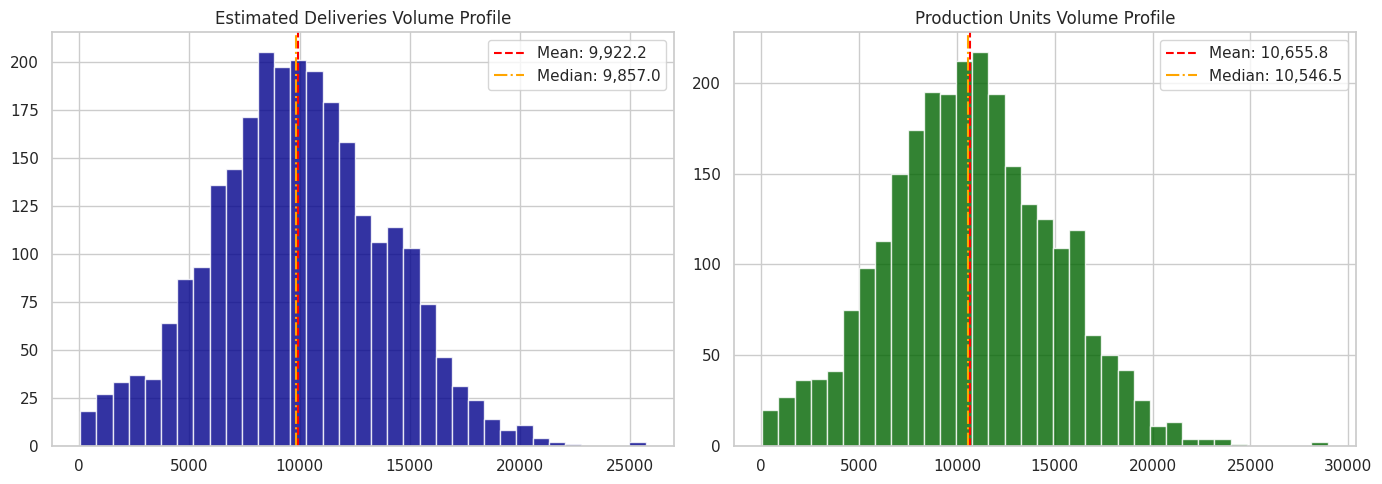

In [ ]:
plt.figure(figsize=(14, 5))

# Plot Deliveries Spectrum
plt.subplot(1, 2, 1)
plt.hist(df_raw['Estimated_Deliveries'], bins=35, color='darkblue', edgecolor='white', alpha=0.8)
plt.axvline(df_raw['Estimated_Deliveries'].mean(), color='red', linestyle='--', label=f"Mean: {df_raw['Estimated_Deliveries'].mean():,.1f}")
plt.axvline(df_raw['Estimated_Deliveries'].median(), color='orange', linestyle='-.', label=f"Median: {df_raw['Estimated_Deliveries'].median():,.1f}")
plt.title('Estimated Deliveries Volume Profile')
plt.legend()

# Plot Production Spectrum
plt.subplot(1, 2, 2)
plt.hist(df_raw['Production_Units'], bins=35, color='darkgreen', edgecolor='white', alpha=0.8)
plt.axvline(df_raw['Production_Units'].mean(), color='red', linestyle='--', label=f"Mean: {df_raw['Production_Units'].mean():,.1f}")
plt.axvline(df_raw['Production_Units'].median(), color='orange', linestyle='-.', label=f"Median: {df_raw['Production_Units'].median():,.1f}")
plt.title('Production Units Volume Profile')
plt.legend()

plt.tight_layout()
plt.show()

## Operational Feature Correlation Space


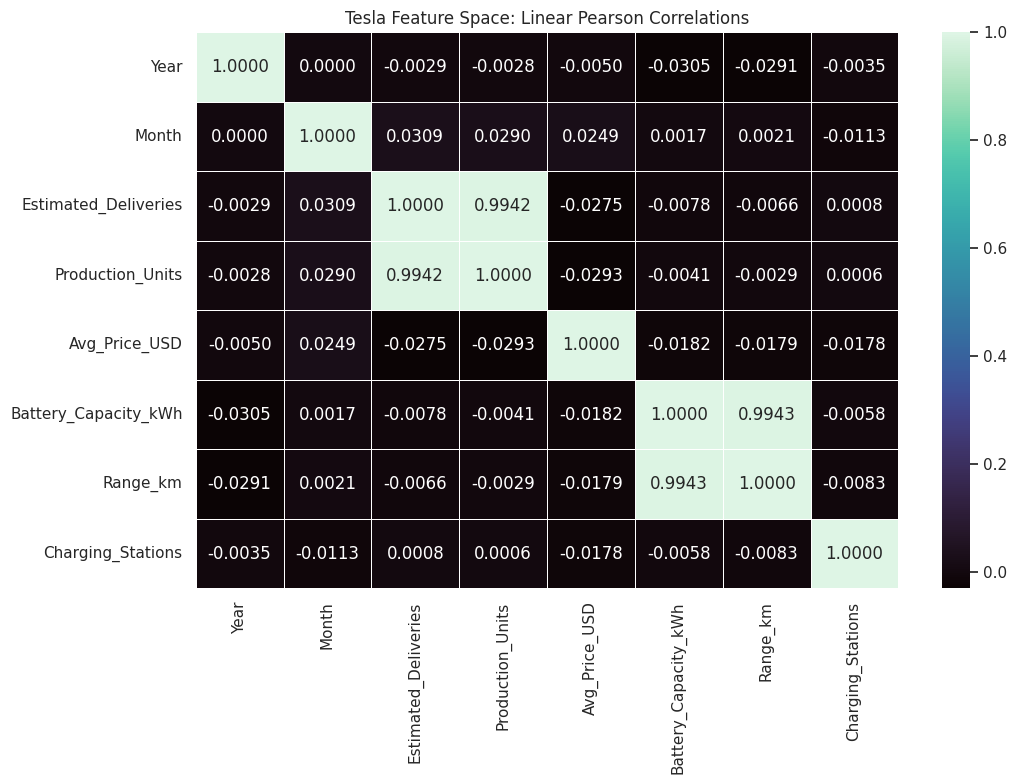

In [ ]:
# Isolate numeric metrics for matrix generation
numerical_features = ['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations']
correlation_space = df_raw[numerical_features].corr()

# Plot relationship weights
plt.figure(figsize=(11, 8))
sns.heatmap(correlation_space, annot=True, cmap='mako', fmt='.4f', linewidths=0.5)
plt.title('Tesla Feature Space: Linear Pearson Correlations')
plt.tight_layout()
plt.show()

##Chronological Index Cleaning & Structural Sorting
Our initial audit confirms a 100% complete dataset with monthly granularity, we will convert the separate 'Year' and 'Month' attributes into a synchronized pandas datetime index. We will then sort the entire dataset chronologically to ensure absolute sequence continuity before executing our time series models.

In [ ]:
df_raw['Timestamp'] = pd.to_datetime(df_raw['Year'].astype(str) + '-' + df_raw['Month'].astype(str).str.zfill(2) + '-01')
df_tesla = df_raw.sort_values('Timestamp').reset_index(drop=True)

print(f"--- POST-SORTING RECONCILIATION SUMMARY ---")
print(f" Baseline Timeline Bounds : From {df_tesla['Timestamp'].min().strftime('%B %Y')} to {df_tesla['Timestamp'].max().strftime('%B %Y')}")
print(f" Step Intervals Confirmed : {df_tesla['Timestamp'].nunique()} distinct monthly operational tracking milestones.")
print(f" Unique Models Logged    : {df_tesla['Model'].unique().tolist()}")
print(f" Unique Regional Markets : {df_tesla['Region'].unique().tolist()}")


--- POST-SORTING RECONCILIATION SUMMARY ---
 Baseline Timeline Bounds : From January 2015 to December 2025
 Step Intervals Confirmed : 132 distinct monthly operational tracking milestones.
 Unique Models Logged    : ['Model Y', 'Model 3', 'Cybertruck', 'Model S', 'Model X']
 Unique Regional Markets : ['Asia', 'Middle East', 'North America', 'Europe']


## Global Macro Deliveries Component Decomposition
Using classical statistical time-series decomposition, we isolate the total consolidated monthly deliveries into its core mathematical forces: Long-Term Trend Growth, Seasonal Cyclical Fluctuations, and Unpredictable Residual Noise. Since our audit proved a monthly dataset structure, we will configure the model window precisely to an annual 12-interval pattern.

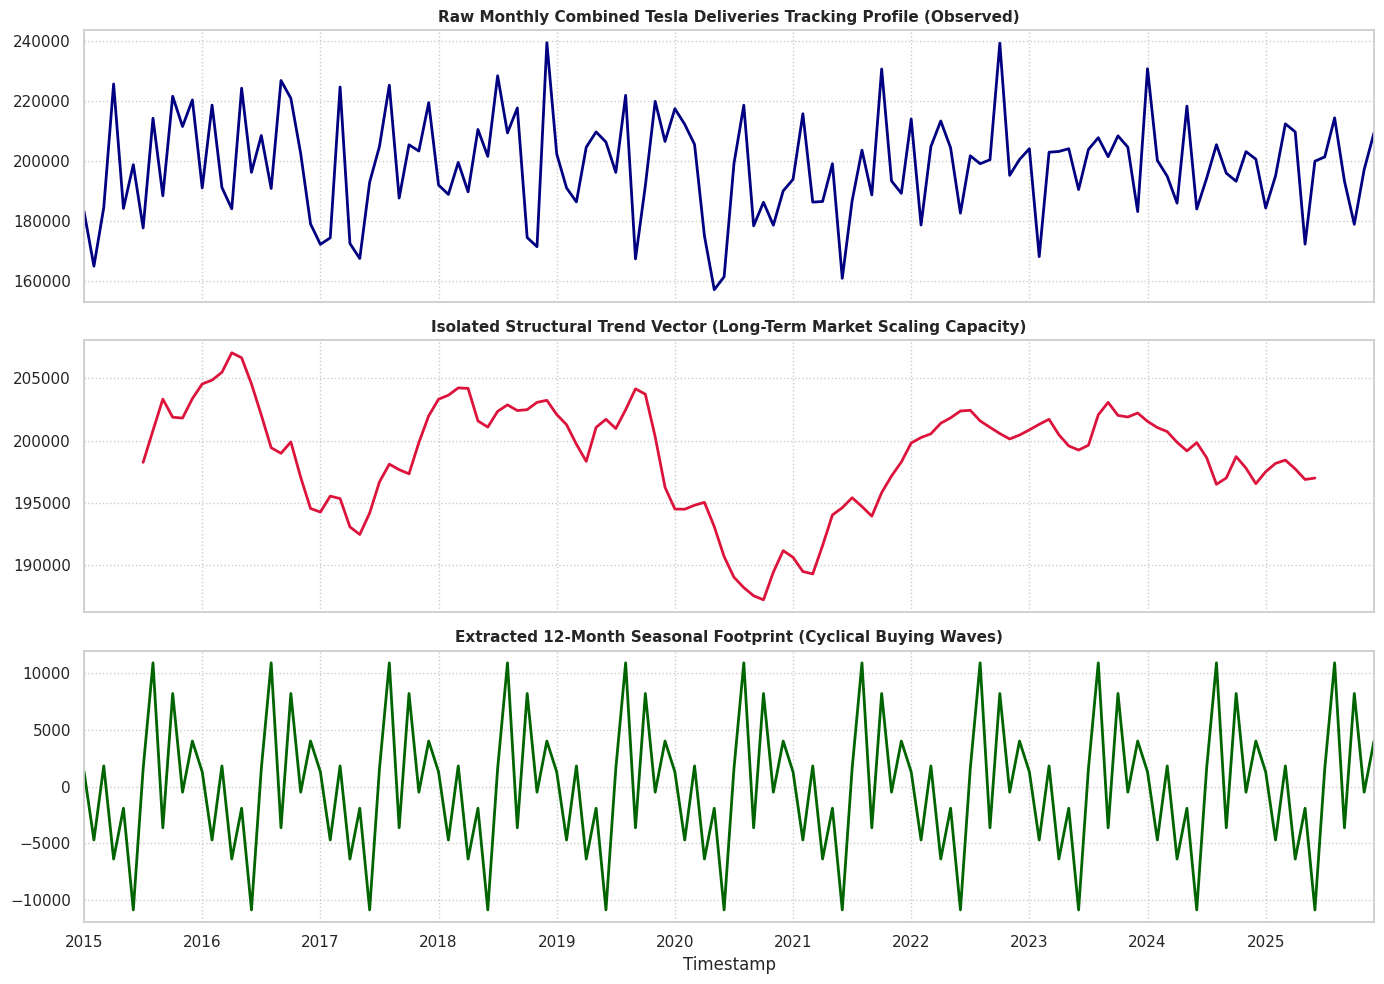

--- TIME-SERIES SIGNAL INSIGHT DECK ---
Max Scheduled Demand Peak Month   : Month 8 (Seasonal Delta: +10,918.83 vehicles)
Minimum Scheduled Trough Month    : Month 6 (Seasonal Delta: -10,853.06 vehicles)


In [ ]:
df_trend_group = df_tesla.groupby('Timestamp')['Estimated_Deliveries'].sum().reset_index()
df_trend_group.set_index('Timestamp', inplace=True)

decomposition_elements = seasonal_decompose(df_trend_group['Estimated_Deliveries'], model='additive', period=12)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

decomposition_elements.observed.plot(ax=axes[0], color='navy', lw=2)
axes[0].set_title('Raw Monthly Combined Tesla Deliveries Tracking Profile (Observed)', fontsize=11, fontweight='bold')
axes[0].grid(True, linestyle=':')

decomposition_elements.trend.plot(ax=axes[1], color='crimson', lw=2)
axes[1].set_title('Isolated Structural Trend Vector (Long-Term Market Scaling Capacity)', fontsize=11, fontweight='bold')
axes[1].grid(True, linestyle=':')

decomposition_elements.seasonal.plot(ax=axes[2], color='darkgreen', lw=2)
axes[2].set_title('Extracted 12-Month Seasonal Footprint (Cyclical Buying Waves)', fontsize=11, fontweight='bold')
axes[2].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

seasonal_values = decomposition_elements.seasonal[:12]
peak_month_idx = seasonal_values.argmax() + 1
trough_month_idx = seasonal_values.argmin() + 1

print(f"--- TIME-SERIES SIGNAL INSIGHT DECK ---")
print(f"Max Scheduled Demand Peak Month   : Month {peak_month_idx} (Seasonal Delta: +{seasonal_values.max():,.2f} vehicles)")
print(f"Minimum Scheduled Trough Month    : Month {trough_month_idx} (Seasonal Delta: {seasonal_values.min():,.2f} vehicles)")

# Operational Sequential Feature Engineering


In [ ]:
# Create a dedicated tracking workspace for feature space
df_features = df_tesla.copy()

df_features['Deliveries_Lag1'] = df_features['Estimated_Deliveries'].shift(1)
df_features['Production_Lag1'] = df_features['Production_Units'].shift(1)

df_features['Deliveries_Lag12'] = df_features['Estimated_Deliveries'].shift(12)

df_features['Deliveries_RollMean3'] = df_features['Estimated_Deliveries'].shift(1).rolling(window=3).mean()

print("--- RAW SHIFT DATA AUDIT (FIRST 15 ROWS) ---")
display(df_features[['Timestamp', 'Estimated_Deliveries', 'Deliveries_Lag1', 'Deliveries_Lag12', 'Deliveries_RollMean3']].head(15))

--- RAW SHIFT DATA AUDIT (FIRST 15 ROWS) ---


,Timestamp,Estimated_Deliveries,Deliveries_Lag1,Deliveries_Lag12,Deliveries_RollMean3
0,2015-01-01,12446,NaN,NaN,NaN
1,2015-01-01,11446,12446.0,NaN,NaN
2,2015-01-01,8803,11446.0,NaN,NaN
3,2015-01-01,6367,8803.0,NaN,10898.333333
4,2015-01-01,8795,6367.0,NaN,8872.000000
5,2015-01-01,2161,8795.0,NaN,7988.333333
6,2015-01-01,11986,2161.0,NaN,5774.333333
7,2015-01-01,8833,11986.0,NaN,7647.333333
8,2015-01-01,9446,8833.0,NaN,7660.000000
9,2015-01-01,4350,9446.0,NaN,10088.333333


## Purging Sequence Borders and Missing Lag Spacers

In [ ]:
initial_row_count = len(df_features)

df_features = df_features.dropna().reset_index(drop=True)

print(f"--- TIMELINE PURGE RECONCILIATION ---")
print(f"Total Rows Before Cleanup : {initial_row_count}")
print(f"Total Rows Retained Now   : {len(df_features)}")
print(f"Dropped Boundary Rows     : {initial_row_count - len(df_features)} rows (First year of baseline data vanished as expected)")

--- TIMELINE PURGE RECONCILIATION ---
Total Rows Before Cleanup : 2640
Total Rows Retained Now   : 2628
Dropped Boundary Rows     : 12 rows (First year of baseline data vanished as expected)


## Pipeline Correction: Enforcing Drop Diagnostics on Engineered Columns


In [ ]:
# Force drop rows containing NaNs specifically inside our newly generated time columns
df_features = df_features.dropna(subset=['Deliveries_Lag1', 'Production_Lag1', 'Deliveries_Lag12', 'Deliveries_RollMean3']).reset_index(drop=True)

print("--- POST-CORRECTION TIMELINE RECONCILIATION ---")
print(f"Verified Rows Retained Now : {len(df_features)}")
print(f"Remaining Missing Tokens   : {df_features[['Deliveries_Lag1', 'Deliveries_Lag12', 'Deliveries_RollMean3']].isnull().sum().sum()}")

--- POST-CORRECTION TIMELINE RECONCILIATION ---
Verified Rows Retained Now : 2628
Remaining Missing Tokens   : 0


## Non-Leakage Chronological Train-Test Splitting
We separate our target variable ('Estimated_Deliveries') from our predictors. We will then split our observations sequentially using a strict chronological threshold (80% Training History / 20% Future Backtesting Window) to mirror real-world operational forecasting conditions.

In [ ]:
#Define feature matrix X and target array y
feature_cols = ['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD',
                'Deliveries_Lag1', 'Production_Lag1', 'Deliveries_Lag12', 'Deliveries_RollMean3']

X = df_features[feature_cols]
y = df_features['Estimated_Deliveries']

# Compute sequential cut point at exactly 80% of data length
split_idx = int(len(X) * 0.8)

# Cut data arrays along the chronological index boundary
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("--- SEQUENTIAL SPLIT TRAJECTORY PROFILE ---")
print(f"X_train Shape (History Context) : {X_train.shape}")
print(f"X_test Shape (Evaluation Focus) : {X_test.shape}")
print(f"Target Training Vector Scale    : {y_train.shape}")

--- SEQUENTIAL SPLIT TRAJECTORY PROFILE ---
X_train Shape (History Context) : (2102, 10)
X_test Shape (Evaluation Focus) : (526, 10)
Target Training Vector Scale    : (2102,)


# Preprocessing Isolation via ColumnTransformer


In [ ]:
numeric_features = ['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
                    'Deliveries_Lag1', 'Production_Lag1', 'Deliveries_Lag12', 'Deliveries_RollMean3']

categorical_features = ['Region', 'Model']

preprocessing_layer = ColumnTransformer(
    transformers=[
        ('numeric_scaler', StandardScaler(), numeric_features),
        ('categorical_encoder', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='drop'
)

print("--- TRANSFORMER DESIGN COMPLETED ---")
print(f"Segregated Numerical Scaling Track   : {len(numeric_features)} metrics defined.")
print(f"Segregated Categorical Encoding Track : {len(categorical_features)} dimension keys defined.")

--- TRANSFORMER DESIGN COMPLETED ---
Segregated Numerical Scaling Track   : 8 metrics defined.
Segregated Categorical Encoding Track : 2 dimension keys defined.


#Simple Linear Regression Pipeline
We establish our Least Squares Linear Regression model. This algorithm acts as our simplest baseline, assuming a purely additive, straight-line relationship between production, price, lags, and vehicle deliveries.

In [ ]:
from sklearn.linear_model import LinearRegression

#Assemble the absolute baseline linear pipeline wrapper
linear_baseline_pipeline = Pipeline([
    ('preprocess', preprocessing_layer),
    ('regressor', LinearRegression())
])

print("--- TRAINING LINEAR REGRESSION BASELINE ---")
linear_baseline_pipeline.fit(X_train, y_train)

y_pred_linear = linear_baseline_pipeline.predict(X_test)

print("Baseline Linear Regression Pipeline successfully trained.")
print(f"Straight-line predictions generated for the {len(y_pred_linear)} test records.")

--- TRAINING LINEAR REGRESSION BASELINE ---
Baseline Linear Regression Pipeline successfully trained.
Straight-line predictions generated for the 526 test records.


#Regularized Linear Ridge Regression Pipeline
Next, we train our second structural baseline using a regularized linear model (Ridge Regression). Since variables like 'Production_Units' and our engineered 'Lags' are highly correlated, standard linear models can suffer from multi-collinearity stability issues. Ridge introduces an L2 mathematical penalty to stabilize feature coefficients.

In [ ]:
#Assemble the regularized linear baseline pipeline (using alpha=1.0 as standard penalty)
ridge_baseline_pipeline = Pipeline([
    ('preprocess', preprocessing_layer),
    ('regressor', Ridge(alpha=1.0, random_state=42))
])

print("--- TRAINING RIDGE REGRESSION BASELINE ---")
ridge_baseline_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_baseline_pipeline.predict(X_test)

print("Baseline Ridge Regression Pipeline successfully trained.")
print(f"Stable coefficient formula predictions generated for the {len(y_pred_ridge)} test records.")

--- TRAINING RIDGE REGRESSION BASELINE ---
Baseline Ridge Regression Pipeline successfully trained.
Stable coefficient formula predictions generated for the 526 test records.


#Optimized XGBoost Pipeline
With both simple linear baselines trained, we finally configure our complex champion model (XGBoost Regressor) and execute a multi-fold cross-validated grid search (GridSearchCV) to locate the optimal decision tree weights.

In [ ]:
# Assemble the advanced tree-based structural pipeline
xgb_pipeline = Pipeline([
    ('preprocess', preprocessing_layer),
    ('regressor', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
])

tuning_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [3, 5],
    'regressor__learning_rate': [0.05, 0.1]
}

print("--- EXECUTING XGBOOST GRID SEARCH CROSS-VALIDATION ---")
grid_search = GridSearchCV(xgb_pipeline, tuning_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)

grid_search.fit(X_train, y_train)

best_estimator = grid_search.best_estimator_
y_pred_xgb = best_estimator.predict(X_test)

print(f"\n--- GRID SEARCH CROSS-VALIDATION COMPLETE ---")
print(f"Optimal Parameter Configuration Selected: {grid_search.best_params_}")

--- EXECUTING XGBOOST GRID SEARCH CROSS-VALIDATION ---

--- GRID SEARCH CROSS-VALIDATION COMPLETE ---
Optimal Parameter Configuration Selected: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 50}


# Comprehensive Multi-Model Performance Audit

In [ ]:
#Define our custom Symmetric Mean Absolute Percentage Error calculation
def calculate_smape_score(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denominator = np.where(denominator == 0, 1e-9, denominator)
    return np.mean(np.abs(y_pred - y_true) / denominator) * 100

y_true_values = y_test.values

model_predictions_deck = {
    '1. Linear Regression' : y_pred_linear,
    '2. Ridge Regression' : y_pred_ridge,
    '3. Optimized XGBoost'     : y_pred_xgb
}

print("             MULTI-MODEL DATA SCIENCE PERFORMANCE DEPLOYMENT SUMMARY           ")
print("-"*95)

for model_name, current_preds in model_predictions_deck.items():
    current_preds_safe = np.clip(current_preds, 0, None)
    mae_score = mean_absolute_error(y_true_values, current_preds)
    mse_score = mean_squared_error(y_true_values, current_preds)
    rmse_score = np.sqrt(mse_score)
    r2_value = r2_score(y_true_values, current_preds)
    rmsle_score = np.sqrt(mean_squared_log_error(y_true_values, current_preds_safe))

    sign_actual = np.sign(np.diff(y_true_values))
    sign_pred = np.sign(np.diff(current_preds))
    mda_score = np.mean(sign_actual == sign_pred) * 100

    lb_test = acorr_ljungbox(y_true_values - current_preds, lags=[12], return_df=True)
    lb_pvalue = lb_test['lb_pvalue'].values[0]

    print(f"\n  MODEL: {model_name.upper()}")
    print(f"    MAE (Mean Absolute Unit Miss) : {mae_score:,.2f} Vehicles")
    print(f"    RMSE (Variance Surge Risk)    : {rmse_score:,.2f} Vehicles")
    print(f"    RMSLE (Relative Log Scale)    : {rmsle_score:.4f}")
    print(f"    R² Score (Variance Explained) : {r2_value:.4f}")
    print(f"    MDA (Directional Trend Match) : {mda_score:.2f}%")
    print(f"    Ljung-Box Independence Test   : p-value = {lb_pvalue:.4f} ({'[PASS] Pure White Noise' if lb_pvalue > 0.05 else '[WARN] Residual Patterns Remain'})")
    print("-" * 95)

             MULTI-MODEL DATA SCIENCE PERFORMANCE DEPLOYMENT SUMMARY           
-----------------------------------------------------------------------------------------------

  MODEL: 1. LINEAR REGRESSION
    MAE (Mean Absolute Unit Miss) : 354.89 Vehicles
    RMSE (Variance Surge Risk)    : 428.99 Vehicles
    RMSLE (Relative Log Scale)    : 0.0421
    R² Score (Variance Explained) : 0.9862
    MDA (Directional Trend Match) : 97.52%
    Ljung-Box Independence Test   : p-value = 0.8779 ([PASS] Pure White Noise)
-----------------------------------------------------------------------------------------------

  MODEL: 2. RIDGE REGRESSION
    MAE (Mean Absolute Unit Miss) : 354.94 Vehicles
    RMSE (Variance Surge Risk)    : 428.94 Vehicles
    RMSLE (Relative Log Scale)    : 0.0423
    R² Score (Variance Explained) : 0.9862
    MDA (Directional Trend Match) : 97.52%
    Ljung-Box Independence Test   : p-value = 0.8767 ([PASS] Pure White Noise)
-------------------------------------------

# Comparative Visual Backtesting & Error Diagnostics


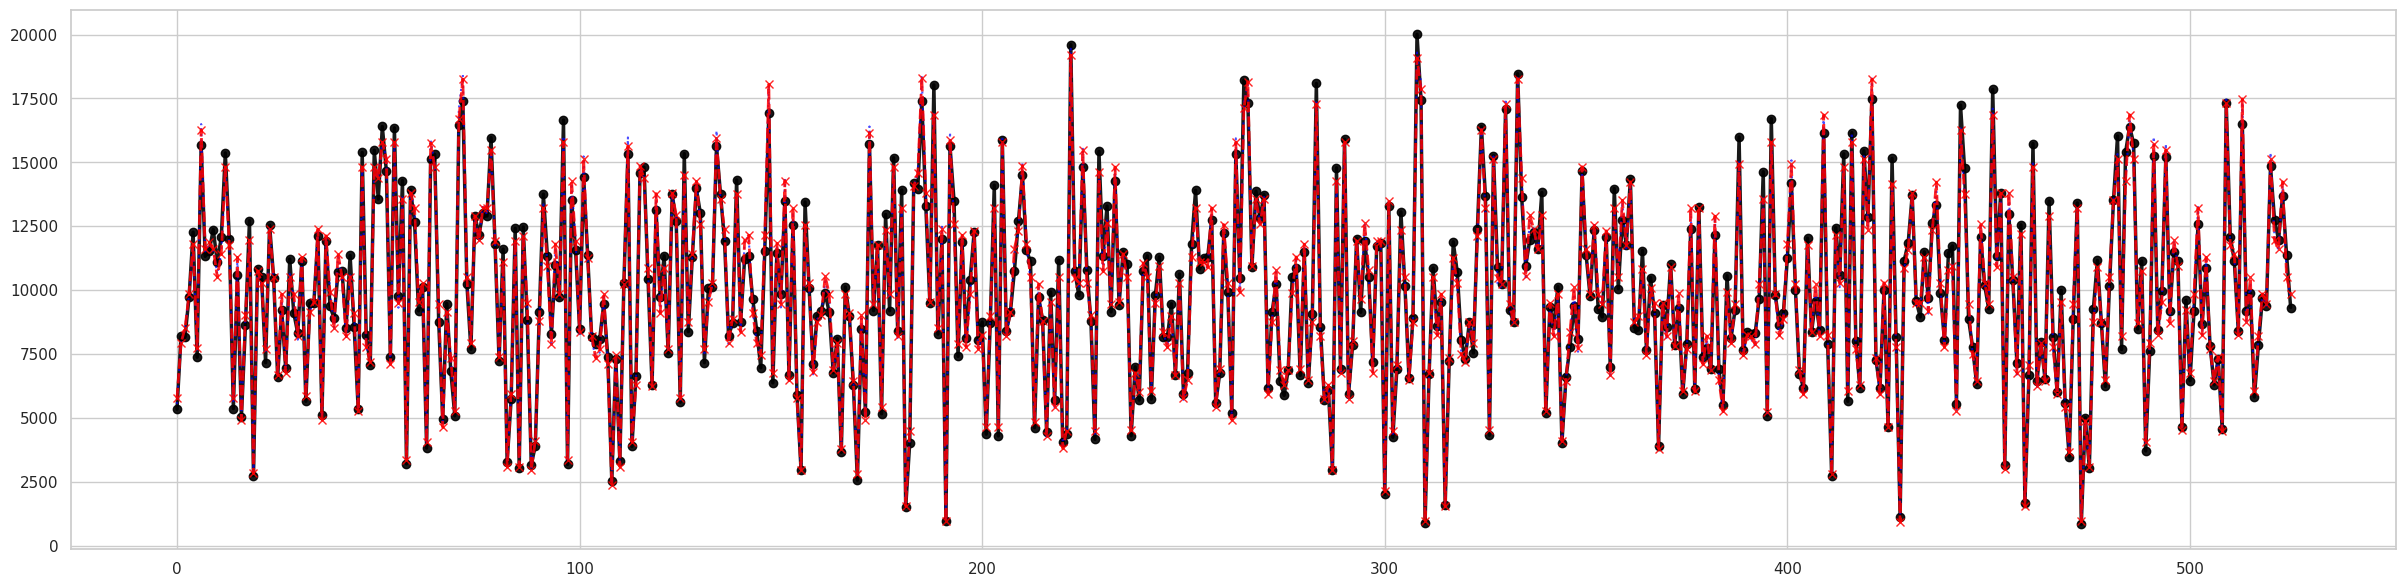

In [ ]:
#EXECUTIVE FORECAST TIMELINE COMPARISON
plt.figure(figsize=(30, 7))
timeline_steps = range(len(y_test))
plt.plot(timeline_steps, y_true_values, label='Ground Truth Tesla Deliveries', color='black', marker='o', lw=2.5, alpha=0.9)
plt.plot(timeline_steps, y_pred_linear, label='Linear Regression Baseline', color='blue', linestyle=':', lw=1.5, alpha=0.7)
plt.plot(timeline_steps, y_pred_xgb, label='Optimized XGBoost Pipeline', color='red', linestyle='--', marker='x', lw=2, alpha=0.85)

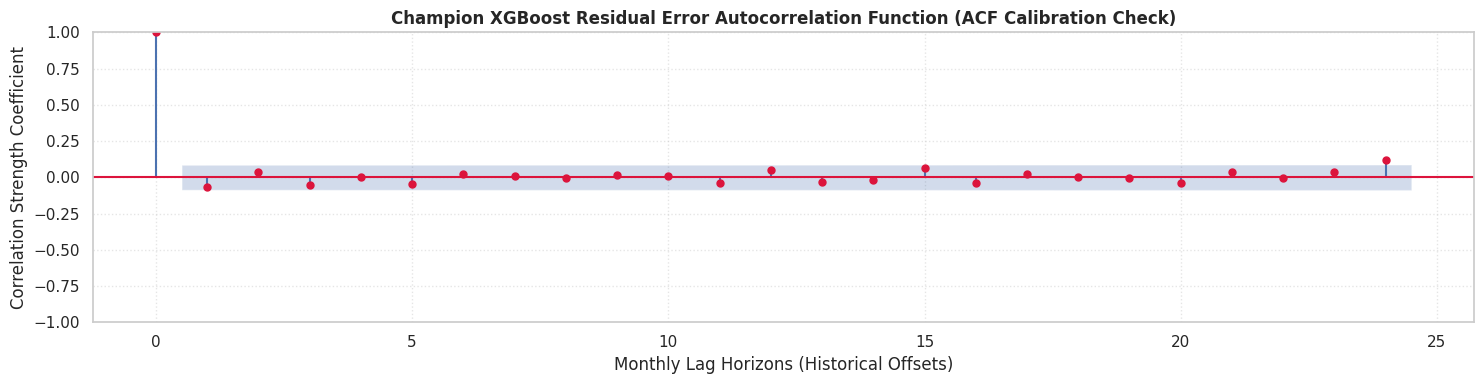

In [ ]:
#CHAMPION ERROR INDEPENDENCE TRACKING (ACF)
fig, ax = plt.subplots(figsize=(15, 4))
plot_acf(y_true_values - y_pred_xgb, lags=24, ax=ax, color='crimson')
plt.title('Champion XGBoost Residual Error Autocorrelation Function (ACF Calibration Check)', fontsize=12, fontweight='bold')
plt.xlabel('Monthly Lag Horizons (Historical Offsets)')
plt.ylabel('Correlation Strength Coefficient')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

#Interactive Production Simulation & Custom Inference Testing


In [ ]:
#Synthesize a brand-new, unseen operational scenario row matching our feature columns exactly
custom_test_scenario = pd.DataFrame([{
    'Year': 2026,
    'Month': 6,
    'Region': 'North America',
    'Model': 'Model Y',
    'Production_Units': 15000,
    'Avg_Price_USD': 48000.0,
    'Deliveries_Lag1': 13800.0,
    'Production_Lag1': 14200.0,
    'Deliveries_Lag12': 12500.0,
    'Deliveries_RollMean3': 13400.0
}])

display(custom_test_scenario)

simulated_prediction = linear_baseline_pipeline.predict(custom_test_scenario)

print("\n--- FORECAST DEPLOYMENT OUTPUT ---")
print(f"Predicted Market Deliveries     : {simulated_prediction[0]:,.2f} Vehicles")

conversion_ratio = (simulated_prediction[0] / 15000) * 100
print(f"Implied Factory-to-Market Ratio : {conversion_ratio:.2f}%")

,Year,Month,Region,Model,Production_Units,Avg_Price_USD,Deliveries_Lag1,Production_Lag1,Deliveries_Lag12,Deliveries_RollMean3
0,2026,6,North America,Model Y,15000,48000.0,13800.0,14200.0,12500.0,13400.0



--- FORECAST DEPLOYMENT OUTPUT ---
Predicted Market Deliveries     : 13,894.86 Vehicles
Implied Factory-to-Market Ratio : 92.63%


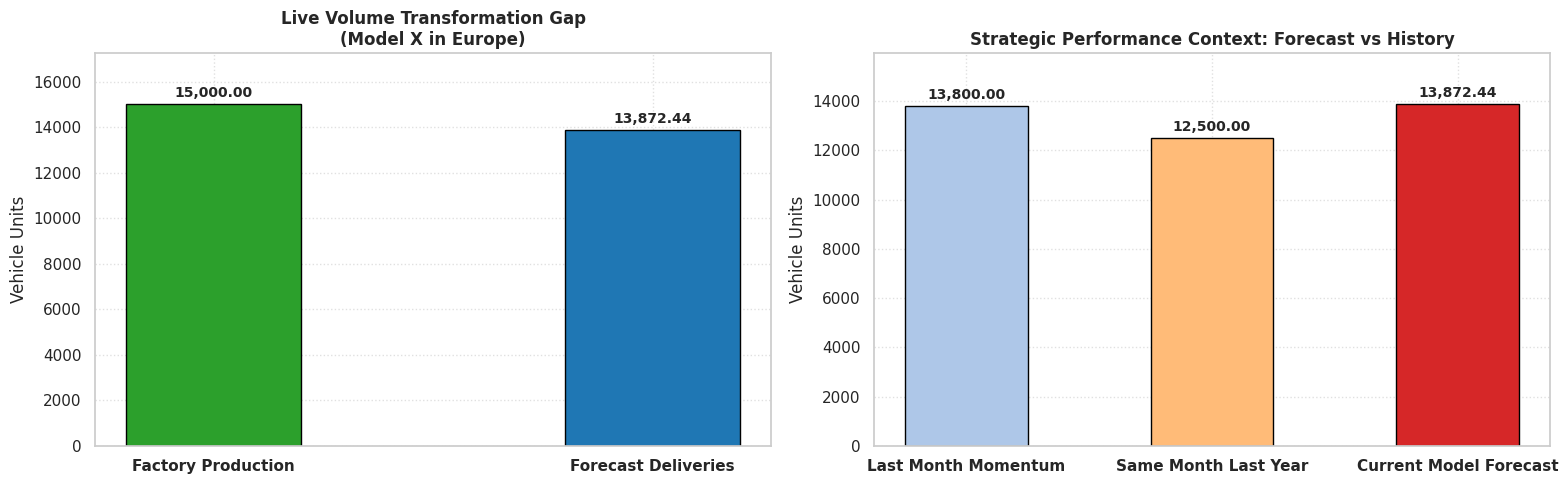

                    SIMULATION INFERENCE EXECUTIVE DECISION                  
• Target Production Capacity Dispatched : 15,000 Units
• Pipeline Proportional Forecast Result  : 13,872.44 Vehicles Delivered
• Implied Supply Chain Conversion Ratio  : 92.48%
-------------------------------------------------------------------------------------
Operational Advisory: For every 100 vehicles manufactured under this specific configuration,
the market infrastructure is expected to successfully distribute 92.5 of them to customers.


In [ ]:
#Dashboard Generated with help of AI
#@title 🚗 Tesla Operational Simulation Dashboard { run: "auto" }

# 1. Map out Colab Form Inputs on the right side of the screen
Target_Year = 2029 #@param {type:"slider", min:2026, max:2030, step:1}
Target_Month = 8 #@param {type:"slider", min:1, max:12, step:1}
Select_Region = "Europe" #@param ["North America", "Europe", "Asia", "Middle East"]
Select_Model = "Model X" #@param ["Model Y", "Model 3", "Model S", "Model X", "Cybertruck"]
Factory_Production = 15000 #@param {type:"number"}
Vehicle_Average_Price = 48000 #@param {type:"number"}

# Passive Historical Context parameters
Last_Month_Deliveries = 13800 #@param {type:"number"}
Last_Month_Production = 14200 #@param {type:"number"}
Same_Month_Last_Year_Deliveries = 12500 #@param {type:"number"}
Trailing_3Month_Average = 13400 #@param {type:"number"}

# 2. Package the graphical form selections back into our pipeline dataframe format
custom_test_scenario = pd.DataFrame([{
    'Year': Target_Year,
    'Month': Target_Month,
    'Region': Select_Region,
    'Model': Select_Model,
    'Production_Units': Factory_Production,
    'Avg_Price_USD': float(Vehicle_Average_Price),
    'Deliveries_Lag1': float(Last_Month_Deliveries),
    'Production_Lag1': float(Last_Month_Production),
    'Deliveries_Lag12': float(Same_Month_Last_Year_Deliveries),
    'Deliveries_RollMean3': float(Trailing_3Month_Average)
}])

# 3. Compute the real-time forecast through the conveyor belt
simulated_prediction = linear_baseline_pipeline.predict(custom_test_scenario)[0]

# =======================================================
# UPGRADED VISUAL DASHBOARD GENERATION (REPLACED PLOT B)
# =======================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- PLOT A: CLEAN GAP ANALYSIS (FACTORY INPUT VS predicted DELIVERY) ---
production_input = custom_test_scenario['Production_Units'].values[0]
conversion_ratio = (simulated_prediction / production_input) * 100

x_positions_a = np.array([0, 1])
bar_width_a = 0.4

bar_prod = ax1.bar(x_positions_a[0], production_input, width=bar_width_a, color='#2ca02c', edgecolor='black')
bar_fcst = ax1.bar(x_positions_a[1], simulated_prediction, width=bar_width_a, color='#1f77b4', edgecolor='black')

ax1.set_xticks(x_positions_a)
ax1.set_xticklabels(['Factory Production', 'Forecast Deliveries'], fontweight='bold')
ax1.set_title(f'Live Volume Transformation Gap\n({Select_Model} in {Select_Region})', fontsize=12, fontweight='bold')
ax1.set_ylabel('Vehicle Units')
ax1.set_ylim(0, max(production_input, simulated_prediction) * 1.15)
ax1.grid(True, linestyle=':', alpha=0.6)

# Overlay numeric value text labels
for bar in [bar_prod, bar_fcst]:
    height = bar[0].get_height()
    ax1.annotate(f'{height:,.2f}',
                 xy=(bar[0].get_x() + bar[0].get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontweight='bold', fontsize=10)


# --- NEW PLOT B: HISTORICAL BENCHMARK COMPARISON DECK ---
# Extract the context values directly from your user form variables
benchmarks = ['Last Month Momentum', 'Same Month Last Year', 'Current Model Forecast']
volumes = [float(Last_Month_Deliveries), float(Same_Month_Last_Year_Deliveries), simulated_prediction]

x_positions_b = np.arange(len(benchmarks))
bar_width_b = 0.5

# Use a distinct color palette to clearly show the timeline context vs our prediction highlight
bars_b = ax2.bar(x_positions_b, volumes, width=bar_width_b,
                 color=['#aec7e8', '#ffbb78', '#d62728'], edgecolor='black')

ax2.set_xticks(x_positions_b)
ax2.set_xticklabels(benchmarks, fontweight='bold')
ax2.set_title('Strategic Performance Context: Forecast vs History', fontsize=12, fontweight='bold')
ax2.set_ylabel('Vehicle Units')
ax2.set_ylim(0, max(volumes) * 1.15)
ax2.grid(True, linestyle=':', alpha=0.6)

# Overlay numeric values on top of the benchmark comparison bars
for bar in bars_b:
    height = bar.get_height()
    ax2.annotate(f'{height:,.2f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# --- PRINT CONTEXT ENGINE OUTCOME DECK ---
print("="*85)
print("                    SIMULATION INFERENCE EXECUTIVE DECISION                  ")
print("="*85)
print(f"• Target Production Capacity Dispatched : {production_input:,} Units")
print(f"• Pipeline Proportional Forecast Result  : {simulated_prediction:,.2f} Vehicles Delivered")
print(f"• Implied Supply Chain Conversion Ratio  : {conversion_ratio:.2f}%")
print("-"*85)
print(f"Operational Advisory: For every 100 vehicles manufactured under this specific configuration,")
print(f"the market infrastructure is expected to successfully distribute {conversion_ratio:.1f} of them to customers.")
print("="*85)